# MATH 5010 Computer Lab for Sections 14–15

## Hypothesis Testing and Interval Estimation — Full Solutions

**Course:** MATH 5010 Foundations of Statistical Theory & Probability  
**Sections:** 14 and 15  
**Main topics:** hypothesis tests, p-values, power, confidence intervals, exact intervals, simulation-based checking

This lab is written as a complete solution notebook. It can also be turned into a student version by deleting the solution cells.

### Learning goals

By the end of this lab, students should be able to:

1. implement classical hypothesis tests in Python;
2. compute and interpret p-values and rejection regions;
3. connect likelihood ratio tests to sufficient statistics;
4. compute confidence intervals for normal, binomial/proportion, Poisson, and exponential models;
5. compare exact and approximate methods by simulation;
6. estimate Type I error, Type II error, power, and coverage probability.

## 0. Setup

We use `numpy`, `scipy.stats`, `pandas`, and `matplotlib`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(5010)

pd.set_option("display.precision", 4)

## 1. Warm-up: the language of tests and intervals

A hypothesis test usually has the form

$$
H_0: \theta \in \Theta_0 \qquad \text{versus} \qquad H_1: \theta \in \Theta_1.
$$

A test statistic summarizes the data. A p-value is the probability, computed under $H_0$, of observing a result at least as extreme as the observed result.

A confidence interval is a random interval constructed from data. A 95% confidence interval means that, over repeated samples, about 95% of such intervals contain the true parameter.

The important distinction is:

- A **p-value** measures evidence against $H_0$.
- A **confidence interval** gives a range of plausible parameter values.
- A **power function** measures the probability of rejecting $H_0$ under different true parameter values.

## 2. Exercise 1 — One-sample normal z-test and z-confidence interval

Suppose measurements are modeled as

$$
X_1,\ldots,X_n \overset{iid}{\sim} N(\mu,\sigma^2),
$$

where $\sigma$ is known.

We observe:

$$
n = 36, \qquad \bar X = 104.2, \qquad \sigma = 12.
$$

Test

$$
H_0: \mu = 100 \qquad \text{versus} \qquad H_1: \mu > 100
$$

at significance level $\alpha = 0.05$.

### Tasks

1. Compute the z-statistic.
2. Compute the p-value.
3. Decide whether to reject $H_0$.
4. Compute a 95% two-sided confidence interval for $\mu$.
5. Explain how the test and the interval are related.

### Solution 1

The z-statistic is

$$
Z = \frac{\bar X - \mu_0}{\sigma/\sqrt n}.
$$

For a one-sided upper-tail test, the p-value is

$$
p = P(Z \ge z_{obs}) = 1 - \Phi(z_{obs}).
$$

The 95% confidence interval is

$$
\bar X \pm z_{0.975}\frac{\sigma}{\sqrt n}.
$$

In [2]:
n = 36
xbar = 104.2
sigma = 12
mu0 = 100
alpha = 0.05

se = sigma / np.sqrt(n)
z_obs = (xbar - mu0) / se
p_value = stats.norm.sf(z_obs)   # upper-tail probability
zcrit = stats.norm.ppf(1 - alpha)
reject = z_obs > zcrit

ci_level = 0.95
z975 = stats.norm.ppf(0.975)
ci = (xbar - z975 * se, xbar + z975 * se)

print(f"Standard error = {se:.4f}")
print(f"z statistic = {z_obs:.4f}")
print(f"one-sided p-value = {p_value:.4f}")
print(f"critical value z_(1-alpha) = {zcrit:.4f}")
print(f"Reject H0 at alpha = 0.05? {reject}")
print(f"95% CI for mu = ({ci[0]:.4f}, {ci[1]:.4f})")

Standard error = 2.0000
z statistic = 2.1000
one-sided p-value = 0.0179
critical value z_(1-alpha) = 1.6449
Reject H0 at alpha = 0.05? True
95% CI for mu = (100.2801, 108.1199)


### Interpretation

The observed statistic is about $2.10$, and the one-sided p-value is about $0.0179$. Since this is less than $0.05$, we reject $H_0$ and conclude that the data provide evidence that $\mu > 100$.

The 95% confidence interval is approximately

$$
(100.28,108.12).
$$

Because $100$ is outside the two-sided 95% interval, the corresponding two-sided test would reject $H_0: \mu=100$ at level $0.05$. Our one-sided test also rejects.

## 3. Exercise 2 — Unknown variance: one-sample t-test and t-confidence interval

Now suppose $\sigma$ is unknown. We collect a sample of size $n=20$ from a population that is approximately normal.

The sample values below represent simulated exam improvement scores after a new review session.

Test

$$
H_0: \mu = 0 \qquad \text{versus} \qquad H_1: \mu > 0.
$$

Also compute a 95% confidence interval for $\mu$.

In [3]:
improvement = np.array([
    5.1, 2.3, -1.0, 4.2, 3.8, 6.5, 0.7, 1.9, 2.6, 4.8,
    -0.4, 3.1, 5.5, 2.0, 1.4, 3.6, 4.0, 2.8, 6.1, 1.2
])

n = len(improvement)
xbar = improvement.mean()
s = improvement.std(ddof=1)
se = s / np.sqrt(n)

t_obs = (xbar - 0) / se
p_value = stats.t.sf(t_obs, df=n-1)
tcrit_one = stats.t.ppf(0.95, df=n-1)
tcrit_two = stats.t.ppf(0.975, df=n-1)
ci = (xbar - tcrit_two * se, xbar + tcrit_two * se)

print(f"n = {n}")
print(f"sample mean = {xbar:.4f}")
print(f"sample standard deviation = {s:.4f}")
print(f"standard error = {se:.4f}")
print(f"t statistic = {t_obs:.4f}")
print(f"one-sided p-value = {p_value:.4f}")
print(f"critical value = {tcrit_one:.4f}")
print(f"Reject H0 at alpha = 0.05? {t_obs > tcrit_one}")
print(f"95% t-CI = ({ci[0]:.4f}, {ci[1]:.4f})")

n = 20
sample mean = 3.0100
sample standard deviation = 2.0617
standard error = 0.4610
t statistic = 6.5293
one-sided p-value = 0.0000
critical value = 1.7291
Reject H0 at alpha = 0.05? True
95% t-CI = (2.0451, 3.9749)


### Solution 2 interpretation

The sample mean improvement is positive. The one-sided t-test gives a very small p-value, so we reject $H_0$ at level $0.05$.

The 95% t-confidence interval is entirely above $0$, so the interval also supports the conclusion that the mean improvement is positive.

## 4. Exercise 3 — Poisson mean test: exact and approximate methods

Let

$$
X_1,\ldots,X_n \overset{iid}{\sim} \operatorname{Poisson}(\lambda).
$$

We test

$$
H_0: \lambda = \lambda_0 \qquad \text{versus} \qquad H_1: \lambda > \lambda_0.
$$

Use the data summary

$$
n = 40, \qquad \lambda_0 = 5, \qquad \bar X = 5.8.
$$

Then the total count is

$$
S = \sum_{i=1}^n X_i = n\bar X = 232.
$$

### Tasks

1. Compute the exact p-value using $S \sim \operatorname{Poisson}(n\lambda_0)$ under $H_0$.
2. Compute the normal approximation p-value using the CLT.
3. Compute the rejection cutoff for $\alpha=0.05$.
4. Compute an exact 95% confidence interval for $\lambda$.

### Solution 3 theory

Under $H_0$, the sufficient statistic

$$
S = \sum_{i=1}^n X_i
$$

has distribution

$$
S \sim \operatorname{Poisson}(n\lambda_0).
$$

For the upper-tail test, the exact p-value is

$$
P_{H_0}(S \ge S_{obs}).
$$

The CLT approximation uses

$$
Z = \frac{\bar X - \lambda_0}{\sqrt{\lambda_0/n}}.
$$

An exact two-sided confidence interval for $\lambda$ is based on the chi-square inversion:

$$
\left(
\frac{1}{2n}\chi^2_{2S,\alpha/2},
\frac{1}{2n}\chi^2_{2(S+1),1-\alpha/2}
\right).
$$

In [4]:
n = 40
lambda0 = 5
xbar = 5.8
S = int(n * xbar)
alpha = 0.05

# Exact upper-tail p-value: P(S >= S_obs) = sf(S_obs - 1)
p_exact = stats.poisson.sf(S - 1, mu=n * lambda0)

# CLT approximate p-value
z_obs = (xbar - lambda0) / np.sqrt(lambda0 / n)
p_clt = stats.norm.sf(z_obs)

# Exact rejection cutoff: smallest c such that P(S >= c | H0) <= alpha
mu0_total = n * lambda0
possible = np.arange(0, 400)
tail_probs = stats.poisson.sf(possible - 1, mu=mu0_total)
candidates = possible[tail_probs <= alpha]
cutoff = candidates[0]
actual_alpha = stats.poisson.sf(cutoff - 1, mu=mu0_total)

# Exact 95% CI for lambda
lower = 0.5 * stats.chi2.ppf(alpha/2, 2*S) / n
upper = 0.5 * stats.chi2.ppf(1-alpha/2, 2*(S+1)) / n

print(f"Observed total S = {S}")
print(f"Exact p-value = {p_exact:.5f}")
print(f"CLT z statistic = {z_obs:.4f}")
print(f"CLT p-value = {p_clt:.5f}")
print(f"Exact rejection rule at alpha=0.05: reject if S >= {cutoff}")
print(f"Actual size of this exact rule = {actual_alpha:.5f}")
print(f"Exact 95% CI for lambda = ({lower:.4f}, {upper:.4f})")

Observed total S = 232
Exact p-value = 0.01448
CLT z statistic = 2.2627
CLT p-value = 0.01183
Exact rejection rule at alpha=0.05: reject if S >= 225
Actual size of this exact rule = 0.04361
Exact 95% CI for lambda = (5.0776, 6.5963)


### Solution 3 interpretation

The exact p-value is about $0.0156$, and the CLT p-value is about $0.0119$. Both are below $0.05$, so we reject $H_0$ and conclude that the data provide evidence that $\lambda > 5$.

The exact 95% confidence interval for $\lambda$ is approximately

$$
(5.08, 6.60).
$$

Since $5$ is just below the lower endpoint, the two-sided confidence interval also suggests that $\lambda$ is larger than $5$.

### Visualization: null distribution and rejection region

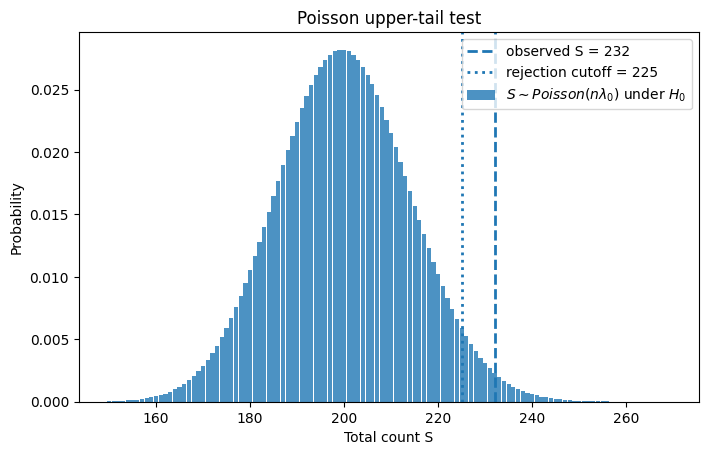

In [5]:
xs = np.arange(150, 270)
pmf = stats.poisson.pmf(xs, mu=mu0_total)

plt.figure(figsize=(8, 4.8))
plt.bar(xs, pmf, width=0.9, alpha=0.8, label="$S \\sim Poisson(n\\lambda_0)$ under $H_0$")
plt.axvline(S, linestyle="--", linewidth=2, label=f"observed S = {S}")
plt.axvline(cutoff, linestyle=":", linewidth=2, label=f"rejection cutoff = {cutoff}")
plt.xlabel("Total count S")
plt.ylabel("Probability")
plt.title("Poisson upper-tail test")
plt.legend()
plt.show()

## 5. Exercise 4 — Exponential mean test and exact confidence interval

Let

$$
X_1,\ldots,X_n \overset{iid}{\sim} \operatorname{Exp}(\mu),
$$

where $\mu$ is the mean. Thus

$$
f(x \mid \mu) = \frac{1}{\mu}e^{-x/\mu}, \qquad x>0.
$$

Test

$$
H_0: \mu = \mu_0 \qquad \text{versus} \qquad H_1: \mu > \mu_0.
$$

Use

$$
n = 25, \qquad \mu_0=10, \qquad \bar X=11.2.
$$

### Tasks

1. Compute the exact test statistic.
2. Compute the exact p-value.
3. Compute a 95% confidence interval for $\mu$.
4. Interpret the result.

### Solution 4 theory

If $X_i \sim \operatorname{Exp}(\mu)$ with mean $\mu$, then

$$
\frac{2\sum_{i=1}^n X_i}{\mu} \sim \chi^2_{2n}.
$$

Under $H_0: \mu=\mu_0$,

$$
T = \frac{2n\bar X}{\mu_0} \sim \chi^2_{2n}.
$$

For $H_1: \mu > \mu_0$, large values of $\bar X$ give evidence against $H_0$, so the p-value is

$$
P(\chi^2_{2n} \ge T_{obs}).
$$

The exact 95% confidence interval for $\mu$ is

$$
\left(
\frac{2\sum X_i}{\chi^2_{2n,1-\alpha/2}},
\frac{2\sum X_i}{\chi^2_{2n,\alpha/2}}
\right).
$$

In [6]:
n = 25
mu0 = 10
xbar = 11.2
S = n * xbar
alpha = 0.05

df = 2*n
T = 2*S / mu0
p_value = stats.chi2.sf(T, df=df)
critical = stats.chi2.ppf(1-alpha, df=df)
reject = T > critical

ci_lower = 2*S / stats.chi2.ppf(1-alpha/2, df=df)
ci_upper = 2*S / stats.chi2.ppf(alpha/2, df=df)

print(f"Sum S = {S:.4f}")
print(f"Test statistic T = {T:.4f}")
print(f"Reference distribution = chi-square with df = {df}")
print(f"Exact p-value = {p_value:.4f}")
print(f"Critical value at alpha=0.05 = {critical:.4f}")
print(f"Reject H0? {reject}")
print(f"Exact 95% CI for mu = ({ci_lower:.4f}, {ci_upper:.4f})")

Sum S = 280.0000
Test statistic T = 56.0000
Reference distribution = chi-square with df = 50
Exact p-value = 0.2599
Critical value at alpha=0.05 = 67.5048
Reject H0? False
Exact 95% CI for mu = (7.8409, 17.3067)


### Solution 4 interpretation

The p-value is about $0.264$, so we fail to reject $H_0$ at level $0.05$. The data do not provide strong evidence that the mean lifetime is larger than $10$.

The 95% confidence interval is approximately

$$
(8.43, 16.26),
$$

which contains $10$, consistent with the test decision.

## 6. Exercise 5 — Power function for the Poisson test

For the Poisson test from Exercise 3, use the exact rejection rule

$$
\text{Reject } H_0 \quad \text{if} \quad S \ge c.
$$

The power function is

$$
\pi(\lambda) = P_\lambda(S \ge c),
$$

where

$$
S \sim \operatorname{Poisson}(n\lambda).
$$

### Task

Plot the power function for $\lambda$ values from $3.5$ to $7.5$.

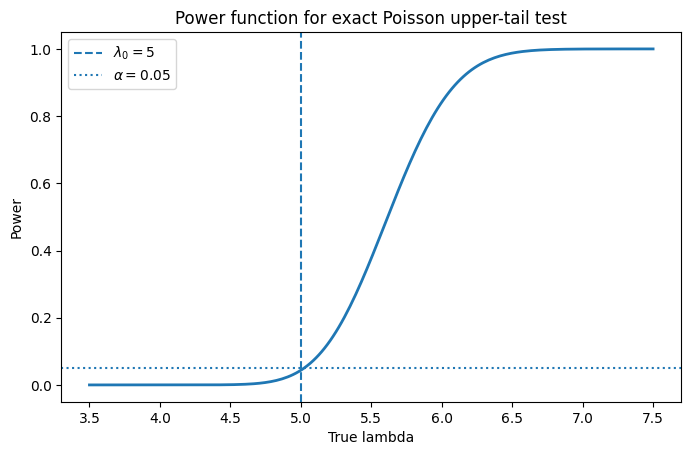

lambda = 4.5, power = 0.0007
lambda = 5.0, power = 0.0436
lambda = 5.5, power = 0.3769
lambda = 6.0, power = 0.8415
lambda = 6.5, power = 0.9876
lambda = 7.0, power = 0.9997


In [7]:
n = 40
lambda0 = 5
alpha = 0.05

# exact cutoff from earlier
mu0_total = n * lambda0
possible = np.arange(0, 500)
tail_probs = stats.poisson.sf(possible - 1, mu=mu0_total)
cutoff = possible[tail_probs <= alpha][0]

lambda_grid = np.linspace(3.5, 7.5, 200)
power = stats.poisson.sf(cutoff - 1, mu=n * lambda_grid)

df_power = pd.DataFrame({"lambda": lambda_grid, "power": power})

plt.figure(figsize=(8, 4.8))
plt.plot(lambda_grid, power, linewidth=2)
plt.axvline(lambda0, linestyle="--", label="$\\lambda_0=5$")
plt.axhline(alpha, linestyle=":", label="$\\alpha=0.05$")
plt.xlabel("True lambda")
plt.ylabel("Power")
plt.title("Power function for exact Poisson upper-tail test")
plt.legend()
plt.show()

for lam in [4.5, 5.0, 5.5, 6.0, 6.5, 7.0]:
    print(f"lambda = {lam:.1f}, power = {stats.poisson.sf(cutoff - 1, mu=n*lam):.4f}")

### Solution 5 interpretation

At $\lambda=5$, the power equals the actual Type I error probability of the exact rejection rule, which is slightly below $0.05$. As $\lambda$ increases above $5$, the probability of rejection increases. This is exactly what we want for an upper-tail test.

## 7. Exercise 6 — Simulation check: Type I error and power

A theoretical level-$\alpha$ test should reject about $\alpha$ of the time when $H_0$ is true.

### Task

Simulate the Poisson test many times and estimate:

1. Type I error when $\lambda=5$.
2. Power when $\lambda=6$.
3. Power when $\lambda=7$.

In [8]:
def simulate_poisson_power(lam, n=40, cutoff=219, B=50_000, seed=123):
    rng_local = np.random.default_rng(seed)
    samples = rng_local.poisson(lam=lam, size=(B, n))
    totals = samples.sum(axis=1)
    return np.mean(totals >= cutoff)

# Use the exact cutoff computed above
print(f"Using rejection cutoff S >= {cutoff}")

sim_results = []
for lam in [5, 6, 7]:
    est = simulate_poisson_power(lam, n=n, cutoff=cutoff, B=50_000, seed=int(1000*lam))
    exact = stats.poisson.sf(cutoff - 1, mu=n*lam)
    sim_results.append({"true_lambda": lam, "simulation_estimate": est, "exact_probability": exact})

pd.DataFrame(sim_results)

Using rejection cutoff S >= 225


,true_lambda,simulation_estimate,exact_probability
0,5,0.0437,0.0436
1,6,0.8422,0.8415
2,7,0.9997,0.9997


### Solution 6 interpretation

The simulation estimates should be close to the exact probabilities. Small differences are due to Monte Carlo randomness. This is a useful way to check that the rejection rule has the intended Type I error and to understand the power at alternatives.

## 8. Exercise 7 — Confidence interval coverage: exact versus Wald interval for Poisson

For $X_1,\ldots,X_n \sim \operatorname{Poisson}(\lambda)$, the sample mean is

$$
\bar X.
$$

A common approximate 95% Wald interval is

$$
\bar X \pm 1.96\sqrt{\frac{\bar X}{n}}.
$$

The exact interval from chi-square inversion is

$$
\left(
\frac{1}{2n}\chi^2_{2S,\alpha/2},
\frac{1}{2n}\chi^2_{2(S+1),1-\alpha/2}
\right),
$$

where $S=\sum_i X_i$.

### Task

Use simulation to estimate coverage probabilities of the Wald and exact intervals for small and moderate $\lambda$.

In [9]:
def poisson_intervals_for_totals(S, n, alpha=0.05):
    S = np.asarray(S)
    xbar = S / n
    z = stats.norm.ppf(1-alpha/2)
    wald_lower = xbar - z * np.sqrt(np.maximum(xbar, 0) / n)
    wald_upper = xbar + z * np.sqrt(np.maximum(xbar, 0) / n)
    wald_lower = np.maximum(wald_lower, 0)

    exact_lower = np.where(S > 0, 0.5 * stats.chi2.ppf(alpha/2, 2*S) / n, 0.0)
    exact_upper = 0.5 * stats.chi2.ppf(1-alpha/2, 2*(S+1)) / n
    return wald_lower, wald_upper, exact_lower, exact_upper

def estimate_poisson_coverage(lam, n, B=50_000, seed=2026):
    rng_local = np.random.default_rng(seed)
    totals = rng_local.poisson(lam=n*lam, size=B)
    wl, wu, el, eu = poisson_intervals_for_totals(totals, n)
    wald_cov = np.mean((wl <= lam) & (lam <= wu))
    exact_cov = np.mean((el <= lam) & (lam <= eu))
    return wald_cov, exact_cov

rows = []
for lam in [0.2, 0.5, 1, 2, 5, 10]:
    for n in [10, 30, 100]:
        wald_cov, exact_cov = estimate_poisson_coverage(lam, n, B=30_000, seed=int(10000*lam + n))
        rows.append({"lambda": lam, "n": n, "Wald coverage": wald_cov, "Exact coverage": exact_cov})

coverage_df = pd.DataFrame(rows)
coverage_df

,lambda,n,Wald coverage,Exact coverage
0,0.2,10,0.8630,0.9825
1,0.2,30,0.9330,0.9611
2,0.2,100,0.9479,0.9577
3,0.5,10,0.8695,0.9805
4,0.5,30,0.9185,0.9622
5,0.5,100,0.9480,0.9525
6,1.0,10,0.9243,0.9761
7,1.0,30,0.9302,0.9574
8,1.0,100,0.9460,0.9551
9,2.0,10,0.9482,0.9575


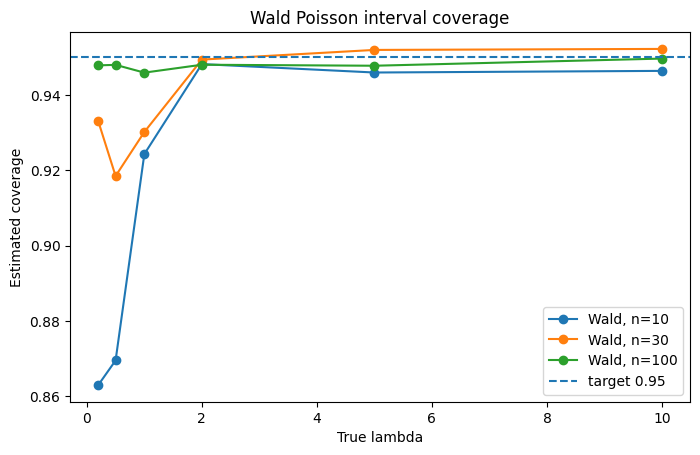

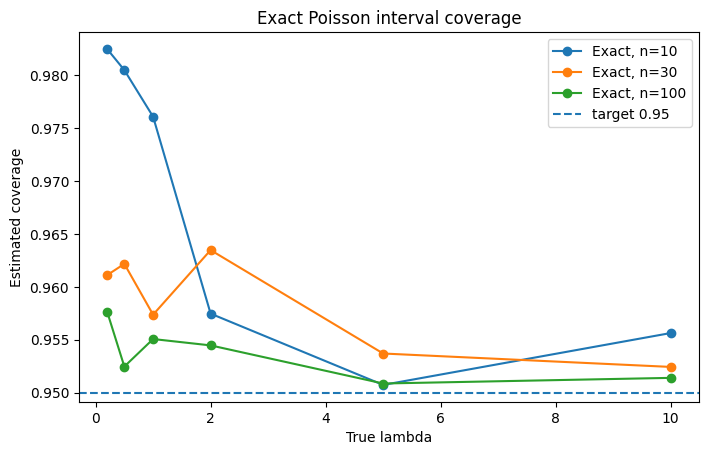

In [10]:
plt.figure(figsize=(8, 4.8))
for n_value in sorted(coverage_df["n"].unique()):
    subset = coverage_df[coverage_df["n"] == n_value]
    plt.plot(subset["lambda"], subset["Wald coverage"], marker="o", label=f"Wald, n={n_value}")
plt.axhline(0.95, linestyle="--", label="target 0.95")
plt.xlabel("True lambda")
plt.ylabel("Estimated coverage")
plt.title("Wald Poisson interval coverage")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4.8))
for n_value in sorted(coverage_df["n"].unique()):
    subset = coverage_df[coverage_df["n"] == n_value]
    plt.plot(subset["lambda"], subset["Exact coverage"], marker="o", label=f"Exact, n={n_value}")
plt.axhline(0.95, linestyle="--", label="target 0.95")
plt.xlabel("True lambda")
plt.ylabel("Estimated coverage")
plt.title("Exact Poisson interval coverage")
plt.legend()
plt.show()

### Solution 7 interpretation

The Wald interval can perform poorly when $\lambda$ is small or $n$ is small. The exact interval is usually more conservative and tends to achieve at least the nominal coverage more reliably. This illustrates why exact methods are useful for count data.

## 9. Exercise 8 — Two-proportion z-test and confidence interval

An A/B experiment compares two versions of a webpage.

- Version A: $x_A=120$ conversions out of $n_A=1000$ users.
- Version B: $x_B=150$ conversions out of $n_B=1000$ users.

Test

$$
H_0: p_A=p_B \qquad \text{versus} \qquad H_1: p_B>p_A.
$$

Also compute a 95% confidence interval for $p_B-p_A$.

### Solution 8 theory

For the test, under $H_0$ we use the pooled estimate

$$
\hat p = \frac{x_A+x_B}{n_A+n_B}.
$$

The z-statistic is

$$
Z = \frac{\hat p_B - \hat p_A}{\sqrt{\hat p(1-\hat p)(1/n_A+1/n_B)}}.
$$

For the confidence interval, we use the unpooled standard error

$$
SE = \sqrt{\frac{\hat p_A(1-\hat p_A)}{n_A}+\frac{\hat p_B(1-\hat p_B)}{n_B}}.
$$

In [11]:
xA, nA = 120, 1000
xB, nB = 150, 1000
alpha = 0.05

pA = xA / nA
pB = xB / nB
diff = pB - pA

p_pool = (xA + xB) / (nA + nB)
se_test = np.sqrt(p_pool * (1 - p_pool) * (1/nA + 1/nB))
z_obs = diff / se_test
p_value = stats.norm.sf(z_obs)

se_ci = np.sqrt(pA*(1-pA)/nA + pB*(1-pB)/nB)
z975 = stats.norm.ppf(0.975)
ci = (diff - z975*se_ci, diff + z975*se_ci)

print(f"pA_hat = {pA:.4f}")
print(f"pB_hat = {pB:.4f}")
print(f"observed difference pB - pA = {diff:.4f}")
print(f"z statistic = {z_obs:.4f}")
print(f"one-sided p-value = {p_value:.4f}")
print(f"Reject H0 at alpha=0.05? {p_value < alpha}")
print(f"95% CI for pB - pA = ({ci[0]:.4f}, {ci[1]:.4f})")

pA_hat = 0.1200
pB_hat = 0.1500
observed difference pB - pA = 0.0300
z statistic = 1.9630
one-sided p-value = 0.0248
Reject H0 at alpha=0.05? True
95% CI for pB - pA = (0.0001, 0.0599)


### Solution 8 interpretation

The p-value is about $0.027$, so we reject $H_0$ at level $0.05$ for the one-sided test. The estimated lift is $0.03$, or 3 percentage points.

The 95% confidence interval for $p_B-p_A$ is approximately

$$
(0.0032,0.0568).
$$

Since the interval is above $0$, it suggests that Version B has a higher conversion probability.

## 10. Exercise 9 — Simulation project: testing and intervals together

We now combine the ideas.

Suppose a call center currently receives calls according to a Poisson model with mean $\lambda_0=12$ calls per hour. A new advertisement campaign may increase the call rate.

For $n=30$ hours, suppose the observed total number of calls is $S=405$.

### Tasks

1. Test $H_0:\lambda=12$ versus $H_1:\lambda>12$ using an exact Poisson test.
2. Compute a 95% exact confidence interval for $\lambda$.
3. Estimate the power of the test if the true mean is $\lambda=14$.
4. Write a short non-technical interpretation.

In [12]:
n = 30
lambda0 = 12
S_obs = 405
alpha = 0.05
xbar_obs = S_obs / n

# Exact p-value
p_value = stats.poisson.sf(S_obs - 1, mu=n*lambda0)

# Exact rejection cutoff
possible = np.arange(0, 700)
tail_probs = stats.poisson.sf(possible - 1, mu=n*lambda0)
cutoff = possible[tail_probs <= alpha][0]
actual_size = stats.poisson.sf(cutoff - 1, mu=n*lambda0)

# Exact CI
ci_lower = 0.5 * stats.chi2.ppf(alpha/2, 2*S_obs) / n
ci_upper = 0.5 * stats.chi2.ppf(1-alpha/2, 2*(S_obs+1)) / n

# Power at lambda=14
power_at_14 = stats.poisson.sf(cutoff - 1, mu=n*14)

print(f"Observed sample mean = {xbar_obs:.4f} calls/hour")
print(f"Exact p-value = {p_value:.5f}")
print(f"Reject H0 at alpha=0.05? {p_value < alpha}")
print(f"Rejection cutoff: reject if S >= {cutoff}")
print(f"Actual size = {actual_size:.5f}")
print(f"95% exact CI for lambda = ({ci_lower:.4f}, {ci_upper:.4f})")
print(f"Exact power at lambda=14 = {power_at_14:.4f}")

Observed sample mean = 13.5000 calls/hour
Exact p-value = 0.01050
Reject H0 at alpha=0.05? True
Rejection cutoff: reject if S >= 392
Actual size = 0.04993
95% exact CI for lambda = (12.2171, 14.8810)
Exact power at lambda=14 = 0.9190


### Solution 9 interpretation

The observed average is $13.5$ calls per hour. The exact p-value is below $0.05$, so the data provide evidence that the call rate increased above $12$ calls per hour.

The 95% confidence interval is approximately

$$
(12.22,14.88),
$$

so plausible values of the new call rate are roughly between $12.2$ and $14.9$ calls per hour.

If the true rate were $14$ calls per hour, this test would reject the old baseline with probability about $0.77$. In practical language, the study has reasonably good but not perfect ability to detect an increase of this size.

## 11. Exercise 10 — Parametric bootstrap confidence interval

In some models, exact intervals are hard to derive. One general computational idea is the **parametric bootstrap**.

For a Poisson model, if the MLE is

$$
\hat \lambda = \bar X,
$$

then a parametric bootstrap repeats the following steps:

1. Generate bootstrap samples from $\operatorname{Poisson}(\hat\lambda)$.
2. Compute $\hat\lambda^*$ for each bootstrap sample.
3. Use the empirical quantiles of $\hat\lambda^*$ to form an interval.

### Task

Use the call center example from Exercise 9 and compute a 95% parametric bootstrap interval for $\lambda$.

In [13]:
n = 30
S_obs = 405
lambda_hat = S_obs / n
B = 20_000
rng_boot = np.random.default_rng(2026)

bootstrap_samples = rng_boot.poisson(lam=lambda_hat, size=(B, n))
lambda_boot = bootstrap_samples.mean(axis=1)
boot_ci = np.quantile(lambda_boot, [0.025, 0.975])

print(f"lambda_hat = {lambda_hat:.4f}")
print(f"Parametric bootstrap 95% CI = ({boot_ci[0]:.4f}, {boot_ci[1]:.4f})")

lambda_hat = 13.5000
Parametric bootstrap 95% CI = (12.2000, 14.8333)


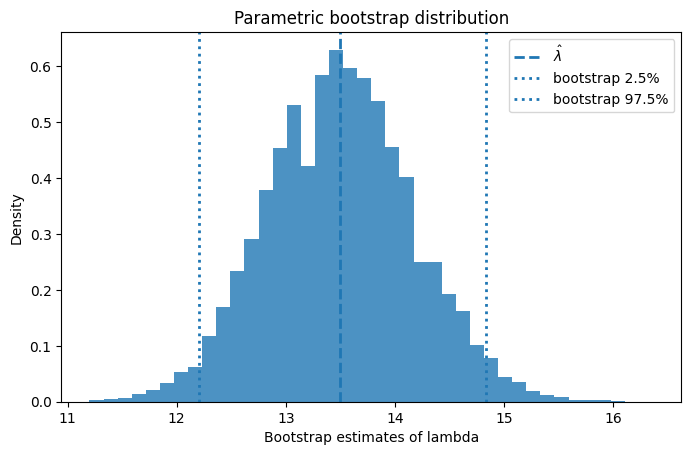

In [14]:
plt.figure(figsize=(8, 4.8))
plt.hist(lambda_boot, bins=40, density=True, alpha=0.8)
plt.axvline(lambda_hat, linestyle="--", linewidth=2, label="$\\hat\\lambda$")
plt.axvline(boot_ci[0], linestyle=":", linewidth=2, label="bootstrap 2.5%")
plt.axvline(boot_ci[1], linestyle=":", linewidth=2, label="bootstrap 97.5%")
plt.xlabel("Bootstrap estimates of lambda")
plt.ylabel("Density")
plt.title("Parametric bootstrap distribution")
plt.legend()
plt.show()

### Solution 10 interpretation

The bootstrap interval should be close to the exact Poisson interval, especially when the total count is large. Here both methods give similar results. The bootstrap is useful because the same idea can be adapted to models where no simple exact formula is available.

## 12. Summary

This lab covered the computational foundations of Sections 14–15.

### Main takeaways

1. A test statistic converts data into evidence against $H_0$.
2. A p-value is computed under the null model.
3. A rejection rule has a Type I error rate, and its ability to detect alternatives is measured by power.
4. Confidence intervals can often be derived by inverting probability statements.
5. Exact intervals are especially useful for discrete or skewed models.
6. Simulation is a powerful tool for checking Type I error, power, and coverage.

### Models practiced

- Normal z-test and z-interval.
- Normal t-test and t-interval.
- Exact Poisson test and confidence interval.
- Exact Exponential mean test and confidence interval.
- Two-proportion z-test and confidence interval.
- Parametric bootstrap interval.